# Clustering of all data

Read in all necessary packages:

In [639]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pandas.io.parsers import read_csv
import scanpy as sc
import numpy as np
from functools import reduce
from anndata import AnnData, read_h5ad
import loompy
import collections
import scipy
import math
from matplotlib.colors import LinearSegmentedColormap
import random
from sklearn.mixture import GaussianMixture
from scipy.stats import poisson

import scipy
import tqdm
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as mpatches

/var/folders/pb/hvc2shb53x194_v0c3h_jyccsf3dhb/T/ipykernel_16752/284414565.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [640]:
sc.set_figure_params(dpi = 80)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

In [641]:
greens_r = sns.blend_palette(['black','#238b45', '#75c477', '#c8e9c1' ], as_cmap = True)
purples_r = sns.blend_palette(['black','#6a51a3', '#9e9bc8', '#dadaeb'], as_cmap = True)
oranges_r = sns.blend_palette(['black','#d94801', '#fd8e3d', '#fdd1a3'], as_cmap = True)

k27_k4 = sns.blend_palette(['#6a51a3', '#9e9bc8', '#dadaeb','#c8e9c1','#75c477','#238b45'], as_cmap = True)
k4_k27 = sns.blend_palette(['#238b45', '#75c477', '#c8e9c1' ,'#dadaeb','#9e9bc8','#6a51a3' ], as_cmap = True)
Green='#238b45'
Purple='#6a51a3'
Orange='#d94801'


In [642]:
cols = ['grey','skyblue','orange','red']
cols2 = ['white','deepskyblue','orange','red','grey']

leg_dict2 = {'negative': 'grey','positive': 'skyblue','going up': 'orange','going down': 'red'}
coldict=dict(zip(list(pd.DataFrame([0,1,2,3,4]).astype('category')[0]), cols2))
leg_dict = {'negative': 'white', 'positive': 'deepskyblue', 'going up': 'orange', 'going down': 'red'}

## formulas

In [647]:
pseudo = []
def bintable(df, stepsize):    
    df = df.sort_values(by = ['hour','pseudotime'],ascending=True)
    df['order'] = list(range(0,len(df)))
    df['steps'] = df['order'].apply(lambda x: np.floor(x/stepsize))
    binned_table_mean = {}
    binned_table_sum = {}
    timepoint = []
    for step in df['steps'].unique():
        binned_table_mean[step] = df[df['steps'] == step].mean(numeric_only=True)
        binned_table_sum[step] = df[df['steps'] == step].sum(numeric_only=True)
        timepoint.append(df[df['steps'] == step]['hour'].value_counts().sort_values(ascending=False).index[0])
    binned_pseudo = pd.DataFrame(pd.DataFrame(binned_table_mean).T['pseudotime'])
    binned_pseudo['timepoint'] = timepoint
    binned_final_mean = pd.DataFrame(binned_table_mean).T.drop(['order','steps','pseudotime'],axis = 1)
    binned_final_sum = pd.DataFrame(binned_table_sum).T.drop(['order','steps','pseudotime'],axis = 1)
    binned_pseudo = binned_pseudo.iloc[:-1,:]
    binned_final_mean = binned_final_mean.iloc[:-1,:]
    binned_final_sum = binned_final_sum.iloc[:-1,:]
    return binned_pseudo, binned_final_mean, binned_final_sum

In [648]:
def gene_ttest(b_df, mean = 2.5, fold = 1.5, pv = 2.3, cutoff = 10):
    start = np.log2((b_df.iloc[0:cutoff])+1)
    stop = np.log2((b_df.iloc[-cutoff:])+1)
    testout = pd.Series(index=start.columns, dtype='float')
    for gene in start.columns:
        s , p = stats.ttest_ind(start[gene],stop[gene])
        testout[gene] = p
    testresults = pd.DataFrame(columns=['fold','p','state','mean'], index = start.columns)
    testresults['fold'] = (stop.mean(axis=0)-start.mean(axis=0))
    testresults['mean'] = (start.mean(axis=0)+stop.mean(axis=0))/2
    testresults['p'] = (-np.log10(testout)).fillna(1)
    testresults['state'] = 0
    testresults.loc[((testresults['mean'] > mean)),'state'] = 1
    testresults.loc[((abs(testresults['fold']) > fold)&(testresults['p'] > pv)&(testresults['mean'] > mean)),'state'] = 2
    
    for gene in list(testresults[(testresults['fold']  < 0 )  & (testresults['state']  == 2)].index):
        testresults.loc[gene, 'state'] = 3   
    
    return testresults


In [700]:
def gene_anova_posthoc(b_df, pseudo_df, mean = 2.5, fold = 1.5, pv = 2.3, cutoff = 5, post_hoc = False):
    
    selected = []
    for ct in pseudo_df['timepoint'].unique():
        median = int(np.median(pseudo_df[pseudo_df['timepoint'] == ct].index))
        selected.append(list(range(median-cutoff, median+cutoff)))

    testout = pd.Series(index=b_df.columns, dtype='float')
    foldchange = pd.Series(index=b_df.columns, dtype='float')
    statistic = []
    pval_tukey = []
    
    print('performing statistics...')
    for gene in b_df.columns:
        
        #perform anova per gene
        s, p = stats.f_oneway(b_df[gene][selected[0]],
                       b_df[gene][selected[1]],
                       b_df[gene][selected[2]],
                       b_df[gene][selected[3]],
                       b_df[gene][selected[4]],
                       b_df[gene][selected[5]]) 
        
        if post_hoc == True:
        # perform tukey post-hoc test
            tukey = stats.tukey_hsd(b_df[gene][selected[0]],
                           b_df[gene][selected[1]],
                           b_df[gene][selected[2]],
                           b_df[gene][selected[3]],
                           b_df[gene][selected[4]],
                           b_df[gene][selected[5]]) 
            # save tukey post-hoc values: statistic (difference) and p-values, for selected steps
            statistic.append([tukey.statistic[0,1], tukey.statistic[1,2], tukey.statistic[2,3], tukey.statistic[3,4], tukey.statistic[4,5]])
            pval_tukey.append([tukey.pvalue[0,1], tukey.pvalue[1,2], tukey.pvalue[2,3], tukey.pvalue[3,4], tukey.pvalue[4,5]])

        # save anova p-value
        testout[gene] = p
        # save mean values of all time points
        means = [b_df[gene][selected[0]].mean(), b_df[gene][selected[1]].mean(), b_df[gene][selected[2]].mean(), b_df[gene][selected[3]].mean(),
             b_df[gene][selected[4]].mean(),b_df[gene][selected[5]].mean()]
        
        # determine fold change
        foldchange[gene] = (max(means) - min(means))
    
    print('calculating values...')
    start = b_df.iloc[selected[0]]
    stop = b_df.iloc[selected[5]]
    testresults = pd.DataFrame(columns=['fold','p','state','mean'], index = b_df.columns)
    testresults['fold'] = foldchange
    testresults['mean'] = (start.mean(axis=0)+stop.mean(axis=0))/2
    testresults['p'] = (-np.log10(testout)).fillna(1)
    #testresults['p_raw'] = testout
    
    print('determining states...')
    testresults['state'] = 0
    testresults.loc[((testresults['mean'] > mean)),'state'] = 1
    testresults.loc[((abs(testresults['fold']) > fold)&(testresults['p'] > pv)&(testresults['mean'] > mean)),'state'] = 2
    
    for gene in list(testresults[(testresults['fold']  < 0 )  & (testresults['state']  == 2)].index):
        testresults.loc[gene, 'state'] = 3   
    
    if post_hoc == True:
        print('saving post-hoc results...')
        testresults[['diff_0-1','diff_1-2','diff_2-3','diff_3-4','diff_4-5']] = pd.DataFrame(statistic, index = b_df.columns, columns = ['diff_0-1','diff_1-2','diff_2-3','diff_3-4','diff_4-5'])[['diff_0-1','diff_1-2','diff_2-3','diff_3-4','diff_4-5']]
        testresults[['ptukey_0-1','ptukey_1-2','ptukey_2-3','ptukey_3-4','ptukey_4-5']] = pd.DataFrame(pval_tukey, index = b_df.columns, columns = ['ptukey_0-1','ptukey_1-2','ptukey_2-3','ptukey_3-4','ptukey_4-5'])[['ptukey_0-1','ptukey_1-2','ptukey_2-3','ptukey_3-4','ptukey_4-5']]
    
    return testresults


## K4me3 TSS tables

In [31]:
tss_selection = pd.read_csv('../data/full_promoter_table_for_K4_based_selection.tsv',
                            index_col = False, header = None, sep = '\t')





/var/folders/pb/hvc2shb53x194_v0c3h_jyccsf3dhb/T/ipykernel_5281/22631508.py:1: DtypeWarning: Columns (0,8) have mixed types. Specify dtype option on import or set low_memory=False.
  tss_selection = pd.read_csv('../data/full_promoter_table_for_K4_based_selection.tsv',


In [86]:
tss_selection#.loc[:,[3,17]]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,10,100013130,100018130,Kitl:1,protein_coding,Kitl,main_an,2,10,100013130,100018130,154.0,160.0,170.0,125.0,279.0,167.0,1,1,1
1,10,100085556,100090556,Kitl:2,protein_coding,Kitl,other,2,10,100085556,100090556,14.0,4.0,10.0,4.0,20.0,2.0,2,0,0
2,10,100333176,100338176,Gm4301:1,protein_coding,Gm4301,main_an,1,10,100333176,100338176,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1
3,10,100338336,100343336,Gm4302:1,protein_coding,Gm4302,main_an,1,10,100338336,100343336,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1
4,10,100343472,100348472,Gm4303:1,protein_coding,Gm4303,main_an,1,10,100343472,100348472,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39696,Y,9199690,9204690,Gm21721:1,protein_coding,Gm21721,main_an,1,Y,9199690,9204690,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1
39697,Y,9344684,9349684,Gm21812:1,protein_coding,Gm21812,main_an,1,Y,9344684,9349684,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1
39698,Y,935283,940283,Kdm5d:3,protein_coding,Kdm5d,other,3,Y,935283,940283,0.0,0.0,0.0,0.0,0.0,0.0,3,0,0
39699,Y,9413648,9418648,Gm21874:1,protein_coding,Gm21874,main_an,1,Y,9413648,9418648,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1


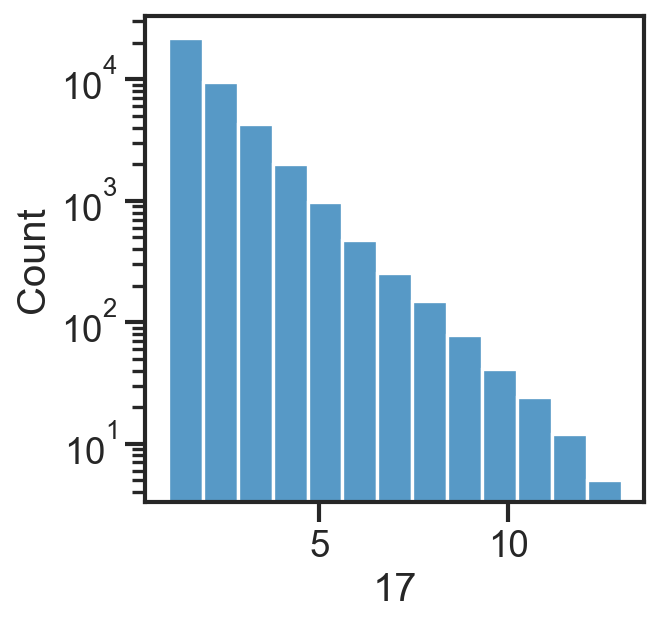

In [55]:
sns.histplot(tss_selection.loc[:,17], bins = 13, palette = 'magma',
            kde = False)

plt.yscale('log')

<AxesSubplot:xlabel='6', ylabel='Count'>

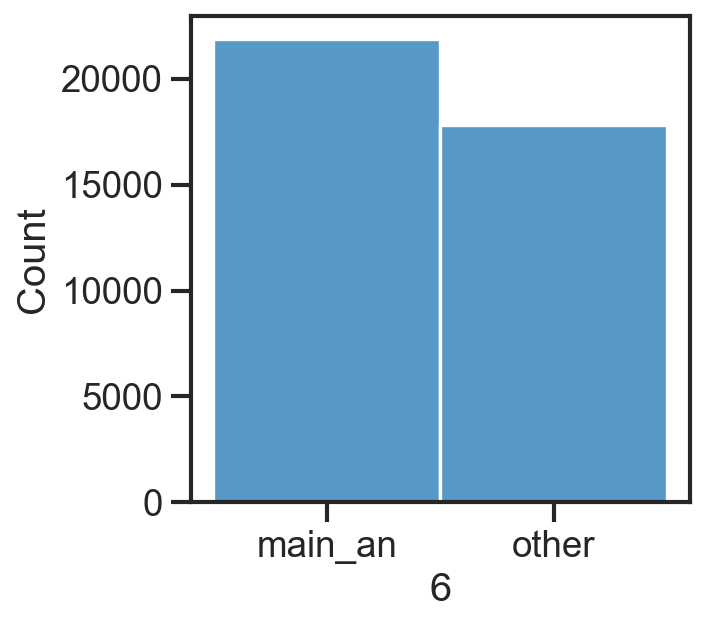

In [89]:
sns.histplot(tss_selection.loc[:,6], bins = 13, palette = 'magma',
            kde = False)

#plt.yscale('log')

In [13]:
df_k4 = pd.read_csv('../data/H3K4me3_Tiso_K4sel_5kb_counts.csv')


In [18]:
df_k4.index = df_k4['Unnamed: 0']


In [507]:
df_k4 = df_k4.drop('Unnamed: 0', axis = 1)

In [59]:
tss_selection.loc[:,17].max()

13

In [90]:
tss_main = tss_selection[tss_selection.loc[:,6] == 'main_an'].loc[:,3]
tss_other = tss_selection[tss_selection.loc[:,6] == 'other'].loc[:,3]




In [91]:
df_main = df_k4.loc[:,np.intersect1d(df_k4.columns,list(tss_main)).astype(str)]
df_other = df_k4.loc[:,np.intersect1d(df_k4.columns,list(tss_other)).astype(str)]


In [92]:
print(df_main.shape)
print(df_other.shape)

print(len(tss_main), len(np.intersect1d(df_main.columns,list(tss_main)).astype(str)))
print(len(tss_other), len(np.intersect1d(df_other.columns,list(tss_other)).astype(str)))


(25344, 21403)
(25344, 4961)
21869 21403
17832 4961


In [94]:
#df_main.to_csv('../data/20231106_TSS_main.csv')

In [95]:
#df_other.to_csv('../data/20231106_TSS_other.csv')

In [15]:
#from scipy import sparse, io

#sparse_df = io.mmread('../data/sparse_df_H3K4me3.mtx')


## dataframes

pseudotime

In [7]:
adata = sc.read_h5ad('../data/20230619_allGastruloids_UMAP_celltypes_incChroms_norm.h5ad')
adata

AnnData object with n_obs × n_vars = 38117 × 27384
    obs: 'batch2', 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'cellnames', 'bc', 'cellname', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_counts_stressgenes', 'n_genes', 'S_score', 'G2M_score', 'phase', 'histone_score', 'mark_binary', 'enrichment', 'coverage', 'QC', 'umap_density_mark', 'predicted_id_E75', 'predicted_id_E85', 'prediction_confidence_E75', 'prediction_confidence_E85', 'predicted_final', 'leiden', 'celltype', 'old_leiden_general', 'old_celltype', 'old_leiden_merge', 'umap_1D', 'umap_1D_rescale', 'celltype_general', 'lineage', 'lin_day', 'hour', 'PT1', 'PT2', 'PT1_avg', 'K4_total', 'K27_total', 'K4_total_log', 'K27_total_log', 'RNA_total_log'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'QC_colors', 'batch_colors', 'celltype_colors', 'celltype_

In [651]:
trajectory = 'Ectoderm'

In [652]:
pseudo = pd.DataFrame(adata.obs['PT1']).rename(columns={'PT1':'pseudotime'})
pseudo = pseudo[(adata.obs['lineage'] == 'Pluripotent') | (adata.obs['lineage'] == trajectory)]
#pseudo = pseudo[adata.obs['celltype'] != 'PGCs']
pseudo = pseudo[adata.obs['celltype'] != 'Epidermis Progenitors']
pseudo = pseudo[adata.obs['celltype'] != 'Epiblast']
#pseudo = pseudo[adata.obs['celltype'] != 'Naive PGCs']
#pseudo = pseudo[adata.obs['celltype'] != 'Reprogramming PGCs']
#pseudo = pseudo[adata.obs['celltype'] != 'mESCs']

pseudo.head(2)

/var/folders/pb/hvc2shb53x194_v0c3h_jyccsf3dhb/T/ipykernel_16752/329000742.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pseudo = pseudo[adata.obs['celltype'] != 'Epidermis Progenitors']
/var/folders/pb/hvc2shb53x194_v0c3h_jyccsf3dhb/T/ipykernel_16752/329000742.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pseudo = pseudo[adata.obs['celltype'] != 'Epiblast']


,pseudotime
index,
PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1_310,30.236847
PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1_302,30.302296


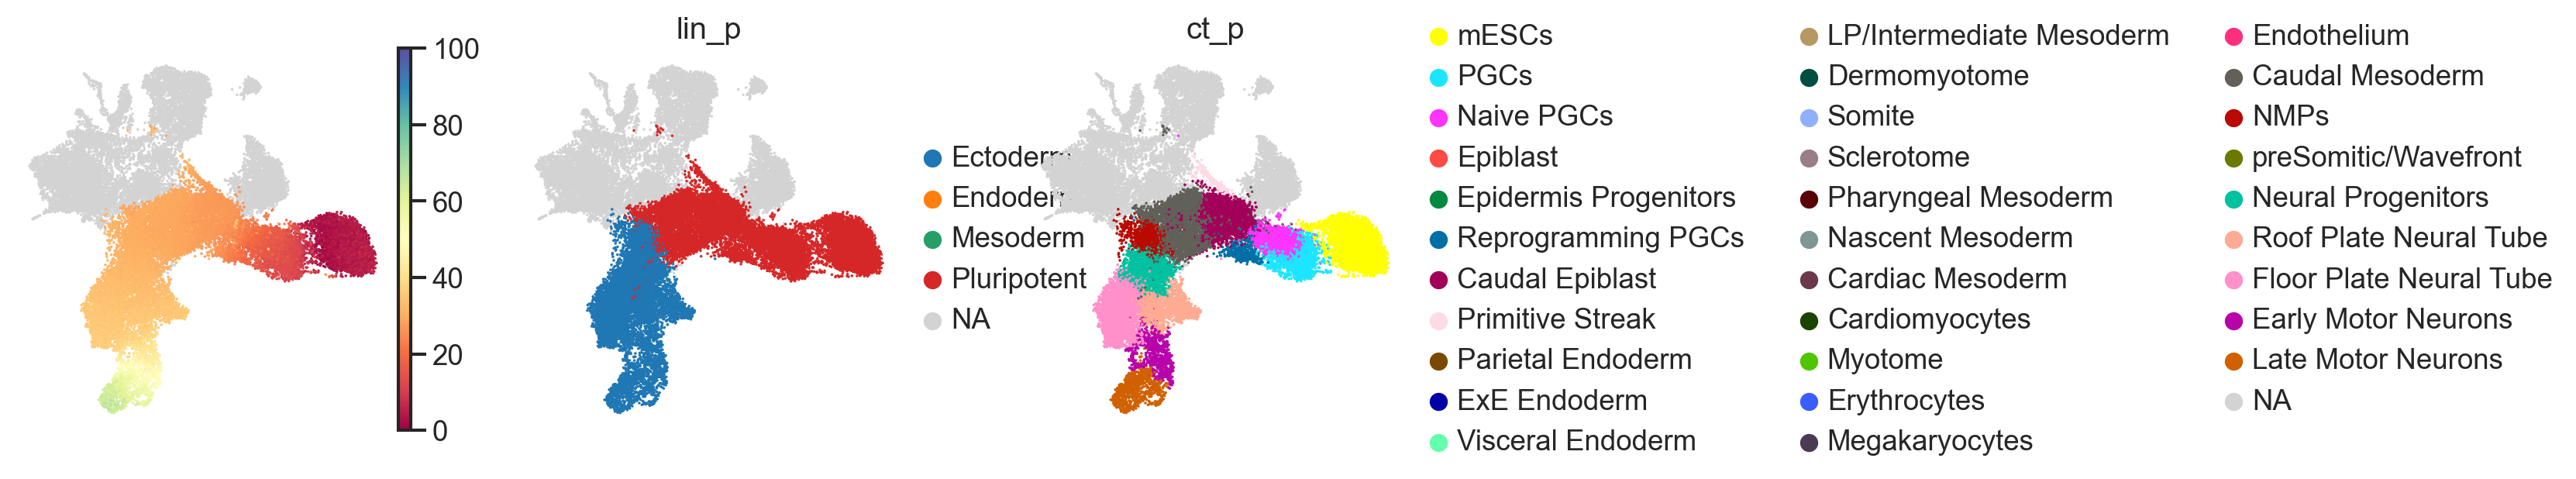

In [653]:
adata.obs['pseudo_p'] = adata.obs.loc[pseudo.index]['PT1']
adata.obs['lin_p'] = adata.obs.loc[pseudo.index]['lineage']
adata.obs['ct_p'] = adata.obs.loc[pseudo.index]['celltype']
sc.pl.umap(adata,color = ['pseudo_p','lin_p','ct_p'], frameon = False, cmap = 'Spectral',size = 10, vmin = 0, vmax = 100, title = '')

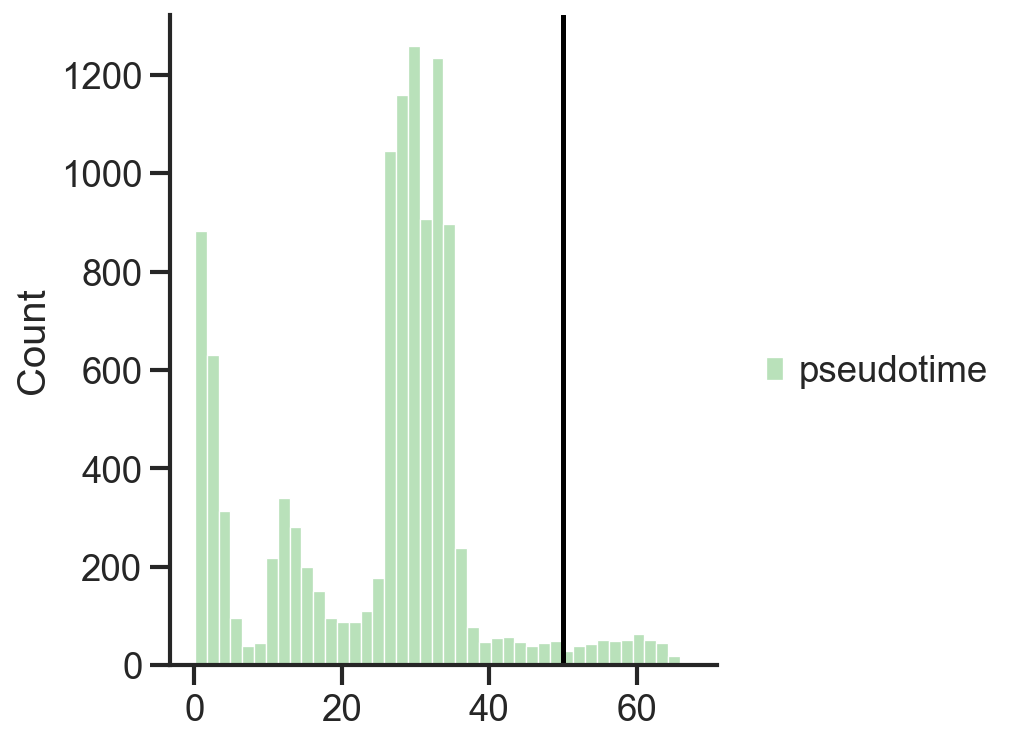

In [654]:
sns.displot(pseudo[(pseudo.index).str.contains('H3K4')], palette = 'Greens_r')
plt.axvline(50,c='black')
plt.show()

In [655]:
#pseudo = pseudo.loc[pseudo['pseudotime'] < 32]

## make binned table

In [658]:
steps = 100

In [659]:
pseudo['hour'] = adata.obs['hour']
#pseudo = pseudo[(pseudo['hour'] == 'mESCs') | (pseudo['hour'] == '72h') | (pseudo['hour'] == '96h') | (pseudo['hour'] == '120h')]

In [15]:
# load K4 table
df_main = pd.read_csv('../data/20231106_TSS_main.csv')

In [18]:
df_main.index = df_main['Unnamed: 0']
df_main = df_main.drop('Unnamed: 0',axis = 1)

In [660]:
common_barcodes = np.intersect1d(df_main.index,pseudo.index).astype(str)

df_main_f = df_main.loc[common_barcodes]
pseudo_f = pseudo.loc[common_barcodes]

In [661]:
df_main_f[['pseudotime','hour']] = pseudo[['pseudotime','hour']]

In [662]:
b_pseudo_all, b_all, b_all_sum = bintable(df_main_f, steps)


In [663]:
b_norm = b_all/np.percentile(b_all, 99)


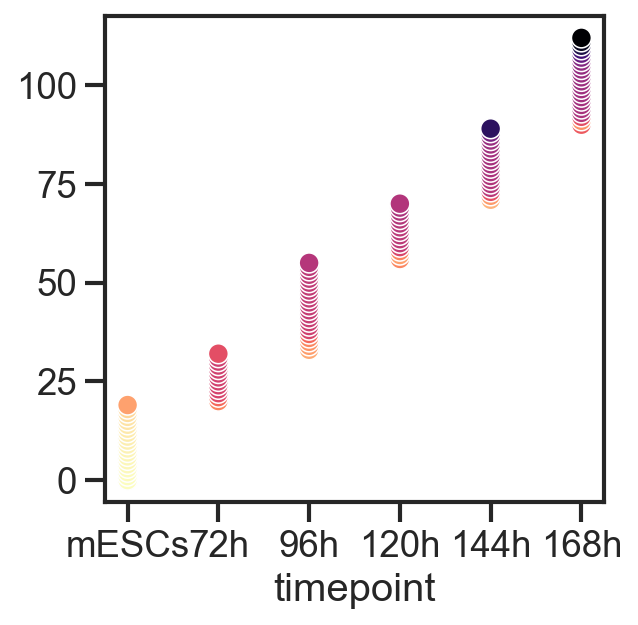

In [664]:
sns.scatterplot(x = b_pseudo_all['timepoint'], y = b_pseudo_all.index, hue = b_pseudo_all['pseudotime'], palette = 'magma_r')
plt.legend([],frameon=False)

In [665]:
from scipy import stats

<AxesSubplot:ylabel='Count'>

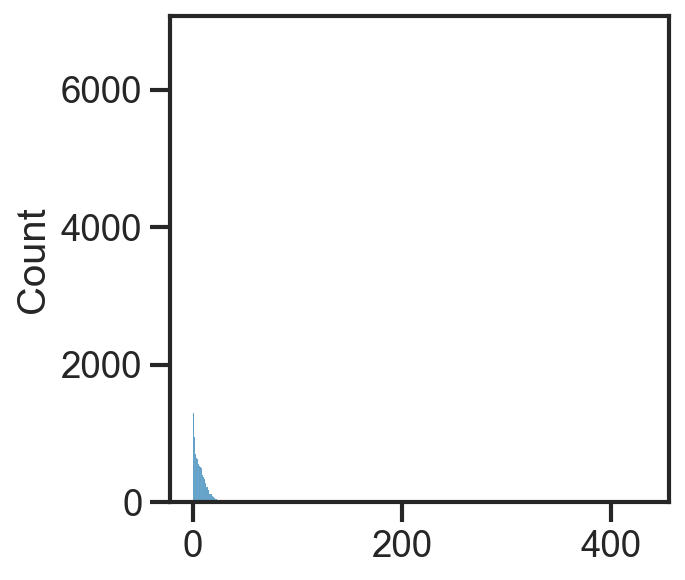

In [666]:
#genes
sns.histplot(b_all.sum(axis=0))

In [667]:
b_all_f = b_all_sum.loc[:,b_all_sum.sum(axis=0) != 0]

<AxesSubplot:ylabel='Count'>

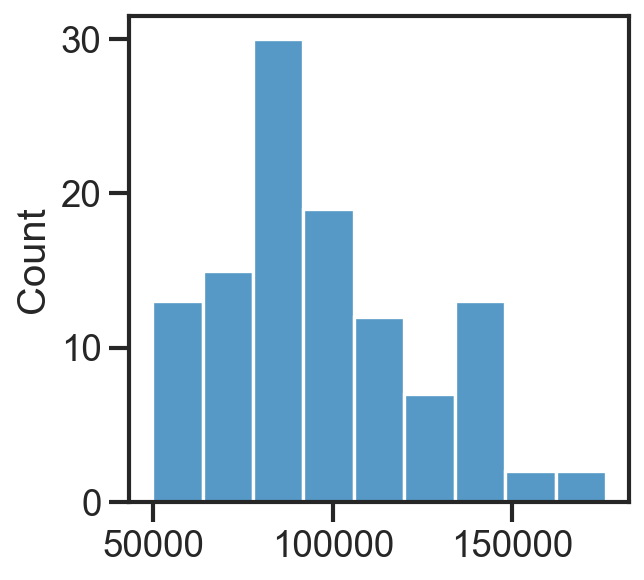

In [668]:
#pseudobulks
sns.histplot(b_all_sum.sum(axis=1))

In [697]:
b_all_f_log = np.log2((b_all_f)+1)

In [703]:
test_anova = gene_anova_posthoc(b_all_f_log.iloc[:,0:100], b_pseudo_all, mean = 1.2, fold = 1.5, pv = 2.3, post_hoc = True)

performing statistics...
calculating values...
determining states...
saving post-hoc results...


In [704]:
test_anova.head(2)

,fold,p,state,mean,diff_0-1,diff_1-2,diff_2-3,diff_3-4,diff_4-5,ptukey_0-1,ptukey_1-2,ptukey_2-3,ptukey_3-4,ptukey_4-5
0610009B22Rik:1,0.358496,0.735796,0,0.050000,-0.100000,0.000000,-0.258496,0.358496,-0.100000,0.983984,1.00000,0.509234,0.167802,0.983984
0610010F05Rik:1,1.181378,1.966678,1,1.732274,1.181378,-0.832193,0.026303,-0.173697,0.364386,0.005583,0.10553,0.999999,0.993671,0.855673


In [705]:
test_anova_only = gene_anova_posthoc(b_all_f_log.iloc[:,0:100], b_pseudo_all, mean = 1.2, fold = 1.5, pv = 2.3, post_hoc = False)

performing statistics...
calculating values...
determining states...


<AxesSubplot:xlabel='p', ylabel='Count'>

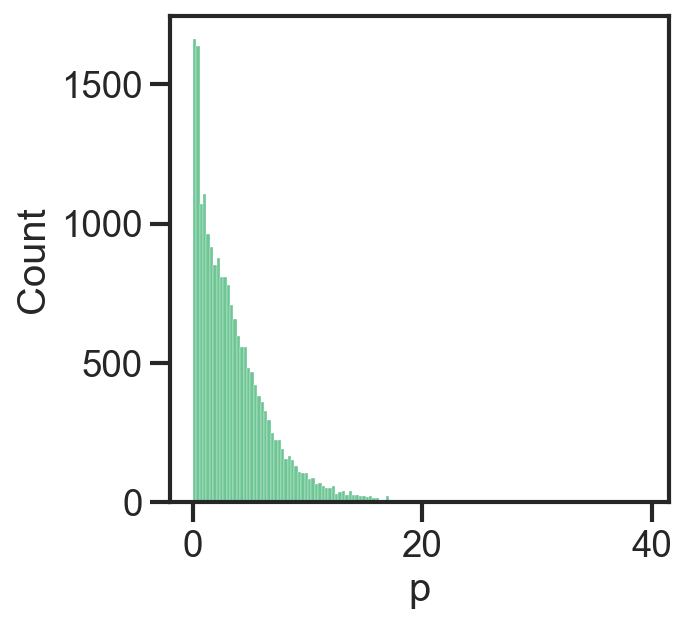

In [385]:
sns.histplot(test_anova['p'], color = 'mediumseagreen')

<AxesSubplot:xlabel='fold', ylabel='Count'>

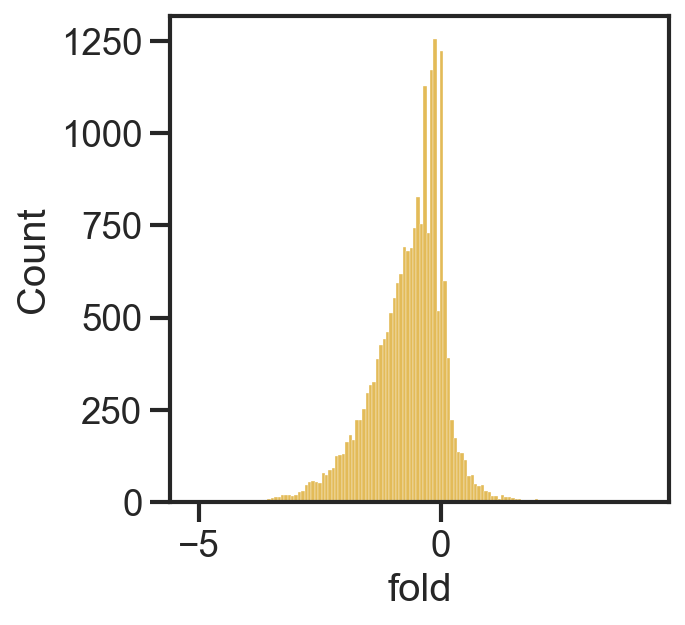

In [392]:
sns.histplot(test_anova['fold'], color = 'goldenrod')
#plt.xlim([-.5,.5])

<AxesSubplot:xlabel='p_raw', ylabel='Count'>

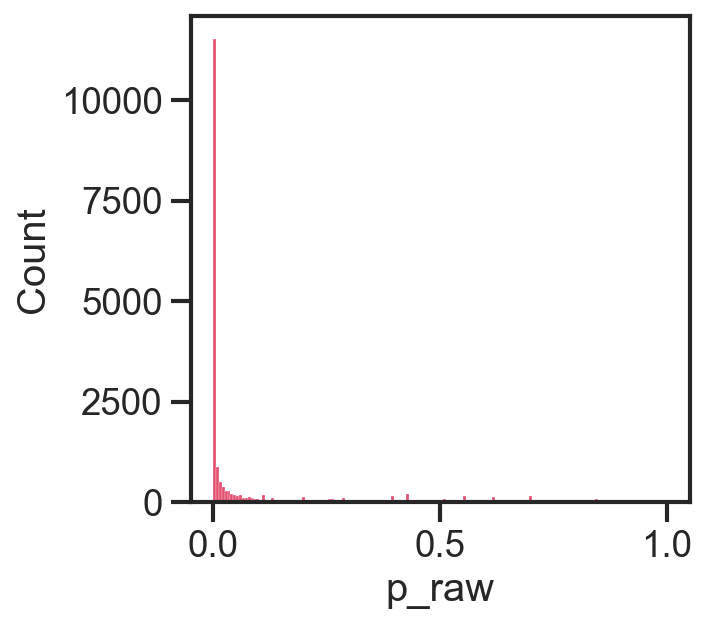

In [400]:
sns.histplot(test_anova['p_raw'], color = 'crimson')
#plt.yscale('log')

<AxesSubplot:xlabel='mean', ylabel='Count'>

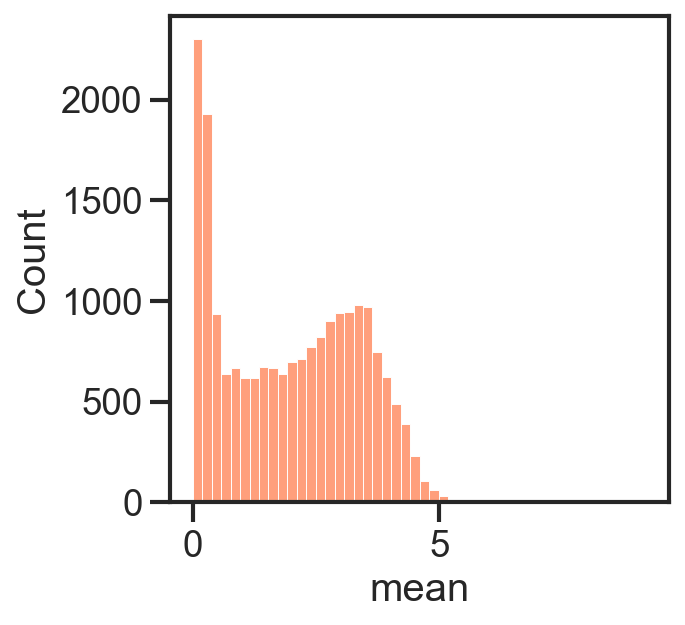

In [393]:
sns.histplot(test_anova['mean'], color = 'coral')
#plt.ylim([0,1700])
#plt.xlim([-0.1,1])

# QC plots

In [389]:
sc.set_figure_params(dpi=80)
sns.set_style('white')
sns.set_context('talk')
sns.set_style('ticks')

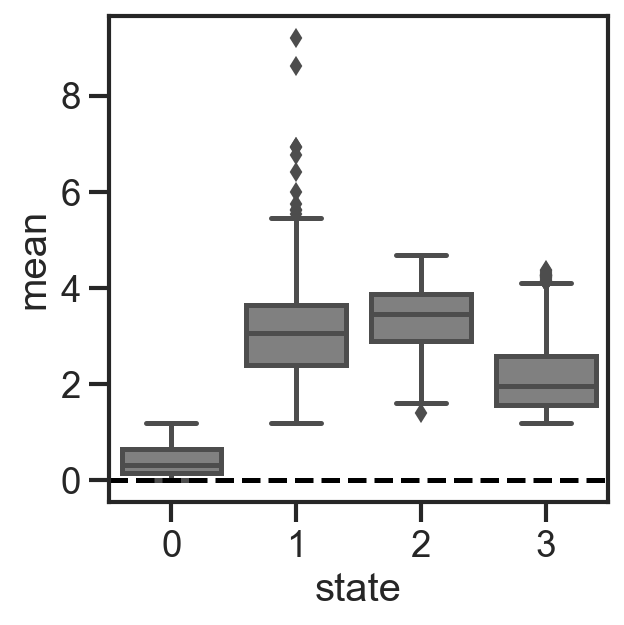

In [390]:
sns.boxplot(x = test_anova['state'].round(1), color = 'grey',
           y = test_anova['mean'])
plt.axhline(0,ls = '--', color = 'black')


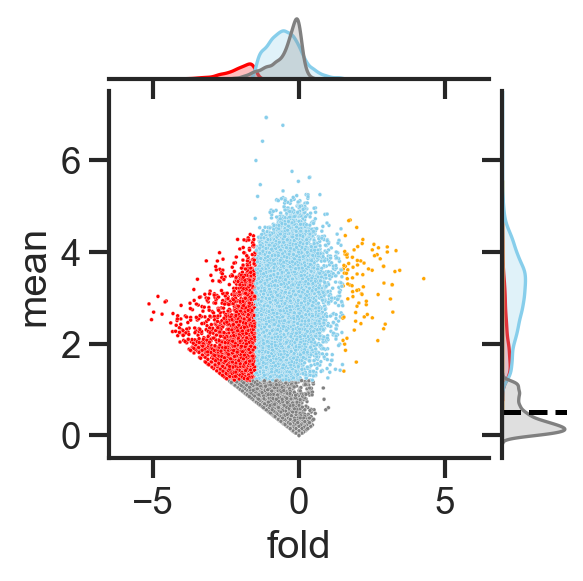

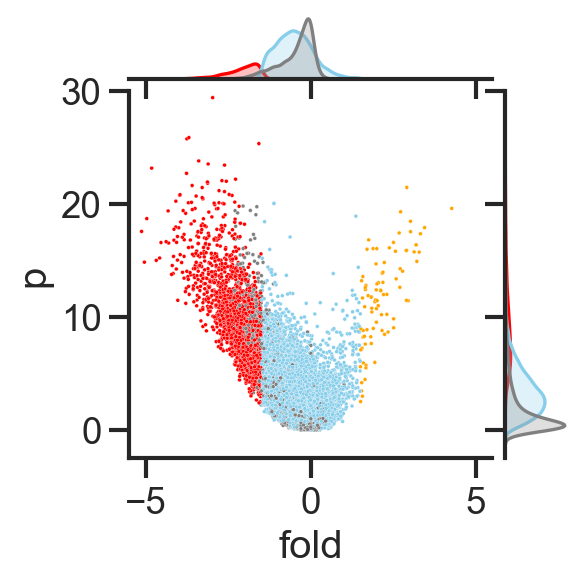

In [399]:
#"scatter" (default), "kde", "hist", "hex", "reg" and "resid".

# all!
kdeplot = sns.jointplot(data = test_anova,
               x = 'fold',s = 3,
               y = 'mean', kind = 'scatter', 
                        hue = 'state', palette = cols,
                        xlim = [-6.5,6.5], ylim = [-.5,7.5],
              height = 4, 
              color = Purple)
plt.axhline(0.5,ls = '--', color = 'black')

#kdeplot.set_axis_labels('', '', fontsize=16)
kdeplot.ax_joint.legend([], frameon = False)


kdeplot = sns.jointplot(data = test_anova,
               x = 'fold',s = 3,
               y = 'p', kind = 'scatter', 
                        hue = 'state', palette = cols,
                        xlim = [-5.5,5.5], ylim = [-2.5,30],
              height = 4, 
              color = Purple)
#kdeplot.set_axis_labels('', '', fontsize=16)
kdeplot.ax_joint.legend([], frameon = False)

In [469]:
def plotHeatmap(genes, cbar = True, sort_order = 'state', aspect_ratio = 0.0005):
    sns.set_context('talk')
    sns.set_style('white')
    states_plot = test_anova.loc[genes,'state']
    
    #order = scipy.cluster.hierarchy.leaves_list(scipy.cluster.hierarchy.linkage(pd.DataFrame(states_plot[sort_order])))
    #states_sorted = states_plot.iloc[order]

    genes = list(states_plot.index)
    
    plot_df2 = pd.concat([b_all[genes], b_pseudo_all['pseudotime']], axis=1)
    plot_df2['binned'] = (plot_df2['pseudotime']).astype(int)
    plot_df2.index = plot_df2['binned']
    plot_df2 = plot_df2.sort_values(by='pseudotime')
    plot_df2 = plot_df2.drop(columns = ['pseudotime','binned'])


    fig,ax = plt.subplots(figsize = (8,len(genes)*aspect_ratio))

    ax = sns.heatmap(plot_df2.T,#.iloc[order], 
                        cmap = greens_r,ax=ax, 
                        cbar = cbar, vmax = 0.22)

    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_ylabel('H3K4me3')
    ax.set_xlabel('pseudotime')
    plt.plot()
    plt.show()

In [442]:
state_0 = list(test_anova[test_anova['state']  == 0].index)
state_1 = list(test_anova[test_anova['state']  == 1].index)
state_2 = list(test_anova[test_anova['state']  == 2].index)
state_3 = list(test_anova[test_anova['state']  == 3].index)

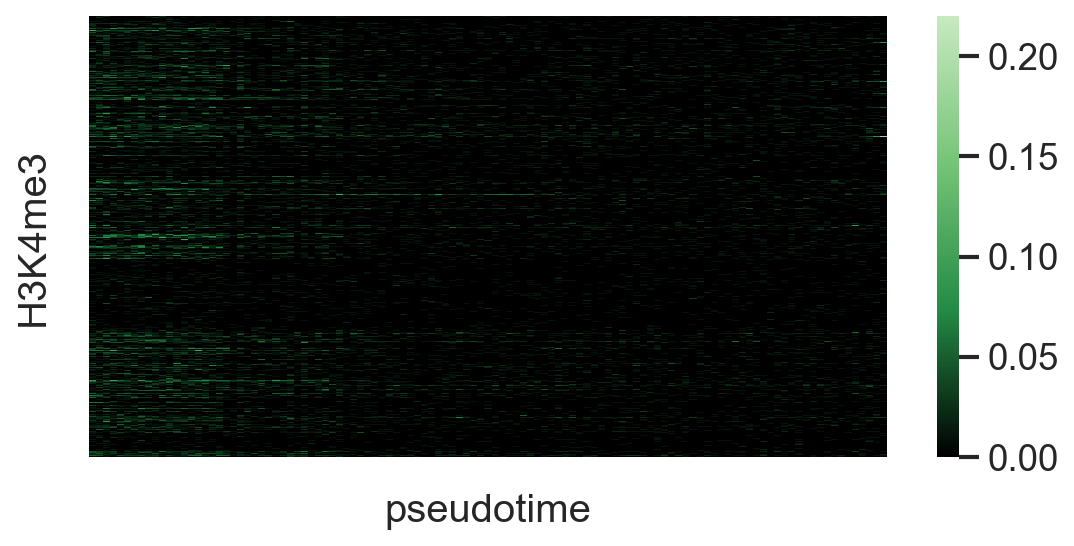

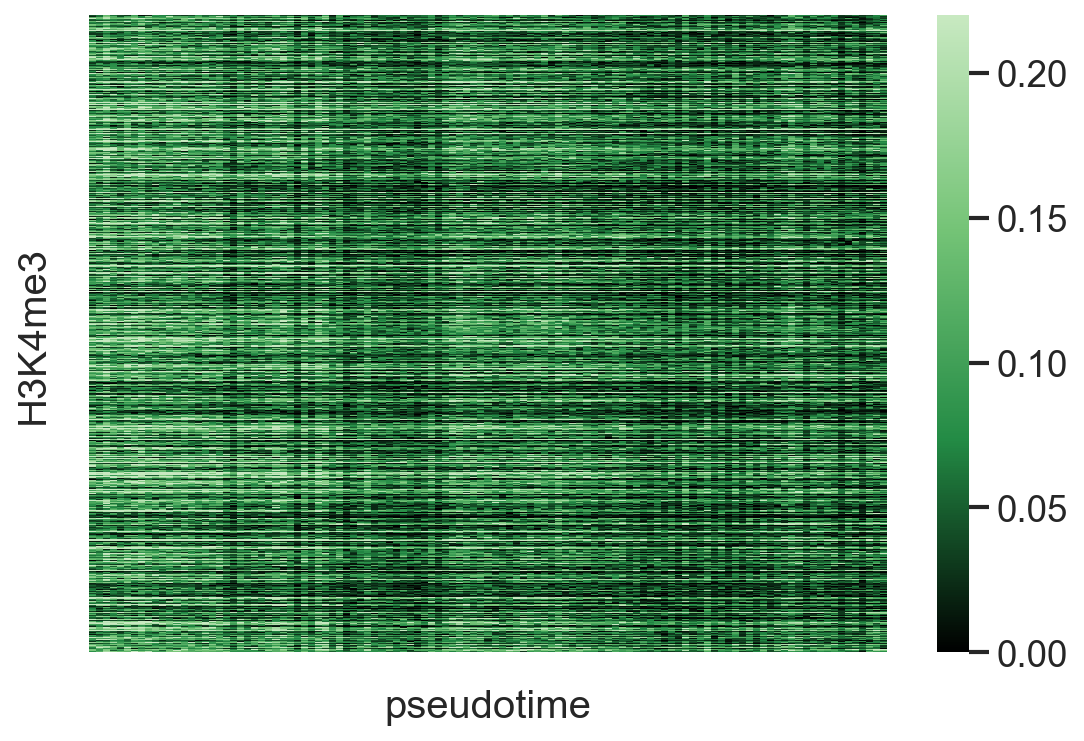

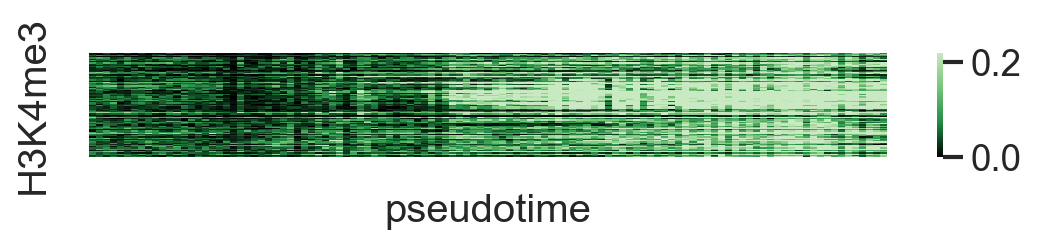

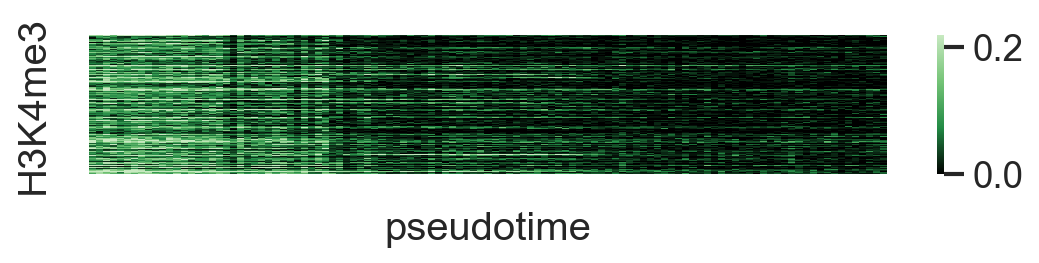

In [472]:
plotHeatmap(state_0)
plotHeatmap(state_1)
plotHeatmap(state_2, aspect_ratio = 0.010)
plotHeatmap(state_3)